In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from dynamics import *
from scipy import stats

In [2]:
#create invasion fitness matrix for invader-driven case
def make_fit(invader):
    k = len(invader)
    fit = np.zeros((k,k))
    for i in range (0, k):
        for j in range (0, k):
            if i != j:
                fit[i,j] = invader[i]
                
    return fit

In [59]:
invader1 = np.array([-0.3, -0.35, -0.95, 0.75, 0.9, -0.6, 0.1, 0.83, 0.85, 0.64, 0.7, 0.66])
invader2 = np.array([-0.3, -0.35, -0.95, 0.78, 0.9, -0.6, 0.1, 0.83, 0.85, 0.64, 0.7, 0.66, 0.5, 0.95, 0.72])

In [60]:
n_array = np.array([12, 15])
#invader = (np.random.rand(n) - 1/2)*2
invader_array = np.array([invader1, invader2], dtype = object)
fit_array = np.array([0, 0], dtype = object)
u0_array = np.array([0, 0], dtype = object)
idx_array = np.array([0, 0], dtype = object)
frequency_array = np.array([0, 0], dtype = object)

for i in range (0, 2):
    invader = invader_array[i]
    fit = make_fit(invader)
    fit_array[i] = fit
        
    #compute the dynamics and number of survival strains
    u0 = np.random.rand(n_array[i]) #create random intitial state
    u0 = u0/sum(u0)
    u0_array[i] = u0
    A, resultat, nc = simu(T = 1500, fit = fit, z0 = u0)
    frequency = resultat.y[:,-1]
    frequency_array[i] = frequency

    #persistent species
    idx = np.where(frequency > 1e-4)[0] 
    idx_array[i] = idx

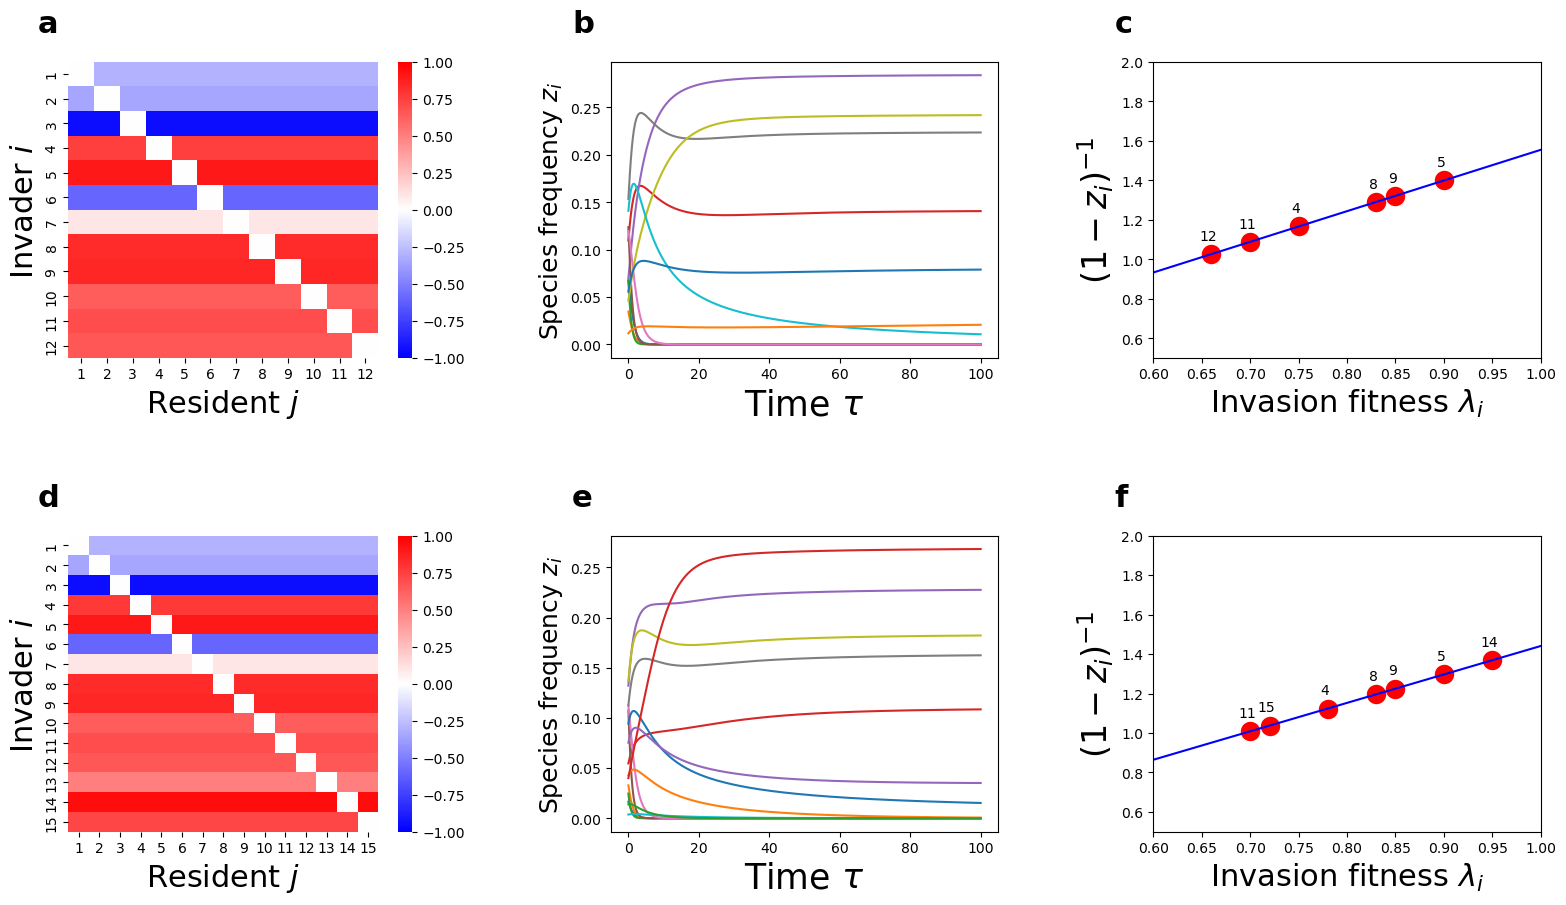

In [62]:
T = 250
details = T*10
    
# Figure
fig, ax = plt.subplots(2, 3, figsize = (19, 10))
plt.subplots_adjust(wspace = 0.4, hspace = 0.6)
label = np.array([['a', 'b', 'c'], ['d', 'e', 'f']])

for i in range (0, 2):
    fit = fit_array[i]
    n = n_array[i]
    range_strain = np.linspace(1, n, n)

    # Panel a
    sns.heatmap(fit, ax = ax[i,0], xticklabels=range(1, n+1), yticklabels=range(1, n+1), 
                vmin = -1, center = 0, vmax = 1, cmap = "bwr", cbar = True)
    ax[i,0].set_xlabel("Resident $j$", fontsize = 22)
    ax[i,0].set_ylabel("Invader $i$", fontsize = 22)

    # Panel b
    u0 = u0_array[i]
    result, ax[i, 1] = plot_dynamics(T = 100, fit = fit, z0 = u0, ax = ax[i,1])
    ax[i, 1].set_ylabel('Species frequency $z_i$', fontsize = 18)
    ax[i, 1].title.set_visible(False)

    # Panel c
    inverse = []
    idx = np.array(idx_array[i])
    invader = invader_array[i]
    frequency = frequency_array[i]
    for j in range (0, n):
        temp = 1/(1- frequency[j])
        inverse.append(temp)
    x = np.linspace(0, 2, 100)
    # Linear regression
    invader_survive = np.array([invader[k] for k in idx])
    inverse_survive = np.array([inverse[k] for k in idx])
        
    slope, intercept, r, p, std_err = stats.linregress(invader_survive, inverse_survive)

    ax[i,2].scatter(invader_survive, inverse_survive, linewidth = 8, color = 'red') #survival ones

    ax[i,2].plot(x, slope*x + intercept, color = 'blue')

    ax[i, 2].set_xlabel('Invasion fitness $\\lambda_i$', fontsize = 22)
    ax[i, 2].set_ylabel('$(1-z_i)^{-1}$', fontsize = 24)
    ax[i, 2].set_xlabel('Invasion fitness $\\lambda_i$', fontsize = 22)


    ax[i, 2].set_xlim(0.6, 1)
    ax[i, 2].set_ylim(0.5, 2)

    for xi, yi, name in zip(invader_survive, inverse_survive, idx +1):
        ax[i, 2].annotate(name, (xi, yi), xytext=(-2, 8), textcoords="offset points", fontsize=10, ha="center", va="bottom")
    
for i in range (0, 2):
    for j in range (0, 3):
        ax[i,j].text(-0.1, 1.1, '{}'.format(label[i,j]), transform=ax[i,j].transAxes, size=22, weight='bold')
    
plt.show()

In [63]:
[s1, s2] = [set(idx_array[0]), set(idx_array[1])]
common = s1&s2
common = np.array(list(common))
print(common)

[ 3  4  7  8 10]


1.5538885947833392 -3.2720651883533236e-06
[1.16541345 1.39849629 1.28972431 1.32080202 1.08771906]
1.440756943332624 3.5413683696639e-07
[1.12379071 1.29668162 1.19582859 1.22464374 1.00853037]


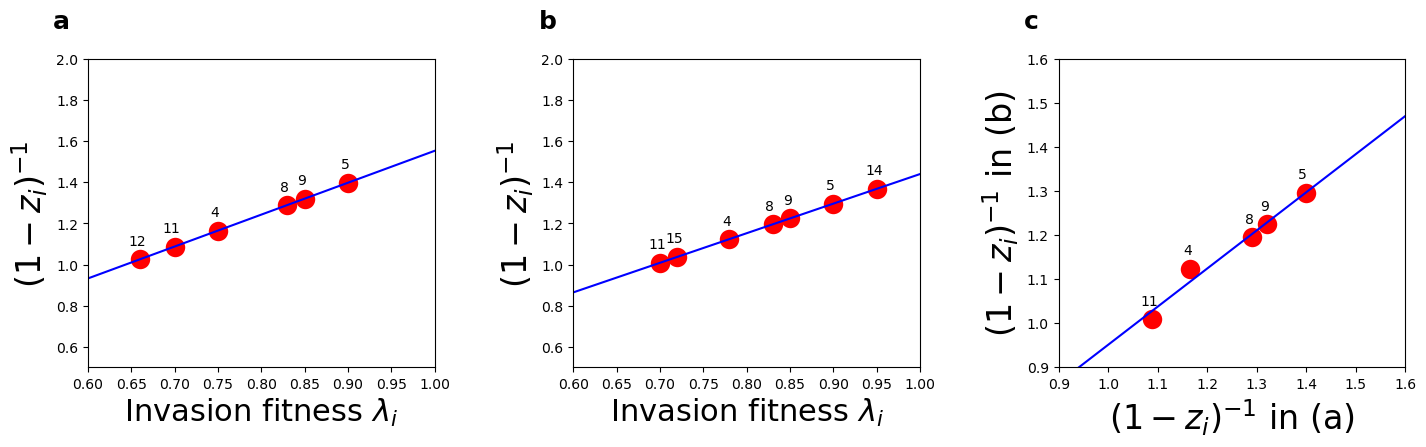

In [66]:
fig, ax = plt.subplots(1, 3, figsize = (17, 4))
plt.subplots_adjust(wspace = 0.4)

label = np.array(['a', 'b', 'c'])
for k in range (0, 3):
    ax[k].text(-0.1, 1.1, '{}'.format(label[k]), transform=ax[k].transAxes, size=18, weight='bold')

inverse_array = np.array([0,0], dtype = object)
x = np.linspace(0, 2, 100)

for i in range (0,2):
    inverse = []
    idx = np.array(idx_array[i])
    invader = invader_array[i]
    frequency = frequency_array[i]
    n = n_array[i]
    for j in range (0, n):
        temp = 1/(1- frequency[j])
        inverse.append(temp)

    # Linear regression
    invader_survive = np.array([invader[k] for k in idx])
    inverse_survive = np.array([inverse[k] for k in idx])
    
    slope, intercept, r, p, std_err = stats.linregress(invader_survive, inverse_survive)
    print(slope, intercept)
    ax[i].scatter(invader_survive, inverse_survive, linewidth = 8, color = 'red') #survival ones

    ax[i].plot(x, slope*x + intercept, color = 'blue')

    ax[i].set_xlabel('Invasion fitness $\\lambda_i$', fontsize = 22)
    ax[i].set_ylabel('$(1-z_i)^{-1}$', fontsize = 24)
    ax[i].set_xlabel('Invasion fitness $\\lambda_i$', fontsize = 22)
    ax[i].set_xlim(0.6, 1)
    ax[i].set_ylim(0.5, 2)

    for xi, yi, name in zip(invader_survive, inverse_survive, idx +1):
        ax[i].annotate(name, (xi, yi), xytext=(-2, 8), textcoords="offset points", fontsize=10, ha="center", va="bottom")
        
    temp = np.array([inverse[k] for k in common])
    print(temp)
    inverse_array[i] = temp
    
#Figure c: linearity between common species between 2 sets
slope_c, intercept_c, r, p, std_err = stats.linregress(inverse_array[0], inverse_array[1])
ax[2].scatter(np.round(inverse_array[0],4), np.round(inverse_array[1],4), linewidth = 8, color = 'red') #survival ones
ax[2].plot(x, slope_c*x + intercept_c, color = 'blue')
ax[2].set_xlabel('$(1-z_i)^{-1}$ in (a)', fontsize = 24)
ax[2].set_ylabel('$(1-z_i)^{-1}$ in (b)', fontsize = 24)
ax[2].set_xlim(0.9, 1.6)
ax[2].set_ylim(0.9, 1.6)

for xi, yi, name in zip(inverse_array[0], inverse_array[1], common +1):
    ax[2].annotate(name, (xi, yi), xytext=(-2, 8), textcoords="offset points", fontsize=10, ha="center", va="bottom")